# Imports and constants 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import json
from lightkurve import LightCurveCollection


In [2]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [3]:
tess_offset = 2457000

In [4]:
ttv_hour = 2* 0.0416667 # 1 hour to days

# Get Lightcurve 

In [5]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC')
print(search_result)


SearchResult containing 47 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
...            ...  ...    ...     ...         ...      ...
 37 TESS Sector 86 2024   SPOC      20   269701147      0.0
 38 TESS Sector 78 2024   SPOC     120   269701147      0.0
 39 TESS Sector 76 2024   SPOC     120   269701147      0

In [6]:
# Use the `.table` attribute to filter and access data
table = search_result.table

# Get missions (sectors) that have 20-second exposures
sectors_with_20s = set(table[table['exptime'] == 20]['mission'])

print(sectors_with_20s)

{'TESS Sector 59', 'TESS Sector 60', 'TESS Sector 75', 'TESS Sector 86', 'TESS Sector 82', 'TESS Sector 76', 'TESS Sector 55', 'TESS Sector 79', 'TESS Sector 78', 'TESS Sector 73', 'TESS Sector 83', 'TESS Sector 85', 'TESS Sector 77', 'TESS Sector 52', 'TESS Sector 48', 'TESS Sector 49', 'TESS Sector 41', 'TESS Sector 56', 'TESS Sector 51'}


In [251]:
# Now build filtered list, preferring 20s over 120s
filtered_results = []

for mission in set(table['mission']):
    if mission in sectors_with_20s:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 20)]
    else:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 120)]
    if len(result) > 0:
        filtered_results.append(result[0])
print(filtered_results)

[SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 59 2022   SPOC      20   269701147      0.0, SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 24 2020   SPOC     120   269701147      0.0, SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 60 2022   SPOC      20   269701147      0.0, SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s             

In [8]:
# Create final SearchResult
from lightkurve.search import SearchResult
from astropy.table import vstack
# Extract the table rows from each mini SearchResult
filtered_tables = [sr.table[0] for sr in filtered_results]

# Stack them into one Astropy Table
stacked_table = vstack(filtered_tables)

# Create final SearchResult
filtered_search = SearchResult(stacked_table)

# Download all matching light curves
lc_collection = filtered_search.download_all()


# lc_collection = search_result.download_all()
print(lc_collection)

LightCurveCollection of 28 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [9]:
# Detrend individually without transit masking
detrended_lcs = []

for lc in lc_collection:
    lc_clean = lc.remove_nans()

    # Choose flattening window based on cadence
    if lc.meta["EXPOSURE"] < 60:
        window = 1001
    else:
        window = 301

    try:
        lc_flat = lc_clean.normalize().flatten(window_length=window).remove_outliers()
        detrended_lcs.append(lc_flat)
    except Exception as e:
        print(f"Skipping one LC due to error: {e}")

combined_lc = LightCurveCollection(detrended_lcs).stitch()

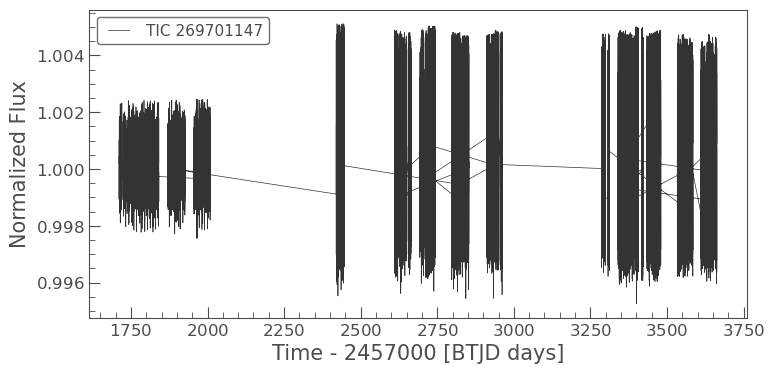

In [10]:
combined_lc.plot()
plt.show()

# Transit predictions based on ephemeris

In [11]:
# from Lubin et al 2024
P_b_guess = 8.88032
Tc_b_bjd = 2458715.356133
Tc_b_guess = Tc_b_bjd - tess_offset
T14_b = 2.939 * 0.0416667

P_c_guess = 28.5805
Tc_c_bjd = 2458726.053366
Tc_c_guess = Tc_c_bjd - tess_offset
T14_c = 4.162 * 0.0416667

P_d_guess = 38.3524
Tc_d_bjd = 2458743.551787
Tc_d_guess = Tc_d_bjd - tess_offset
T14_d = 5.36 * 0.0416667

In [12]:
def ephem(i, P, Tc):
    ttime = Tc + (i*P)
    return ttime

In [67]:
times = combined_lc.time.value
time_min = times.min()
time_max = times.max()
print(time_min)
print(time_max)
total_time = time_max - time_min
print(total_time)
max_transits_b = total_time / P_b_guess
max_transits_c = total_time / P_c_guess
max_transits_d = total_time / P_d_guess
print(max_transits_b)
print(max_transits_c)
print(max_transits_d)

indices_b = np.arange(0, int(max_transits_b)+1)
indices_c = np.arange(0, int(max_transits_c)+1)
indices_d = np.arange(0, int(max_transits_d)+1)


1711.365773734107
3662.827159496912
1951.4613857628049
219.75124609955554
68.27946977004618
50.88237987095474


In [68]:
transit_guess_b = ephem(indices_b, P_b_guess, Tc_b_guess)
transit_guess_c = ephem(indices_c, P_c_guess, Tc_c_guess)
transit_guess_d = ephem(indices_d, P_d_guess, Tc_d_guess)
print(transit_guess_b)
print(len(transit_guess_b))

[1715.356133 1724.236453 1733.116773 1741.997093 1750.877413 1759.757733
 1768.638053 1777.518373 1786.398693 1795.279013 1804.159333 1813.039653
 1821.919973 1830.800293 1839.680613 1848.560933 1857.441253 1866.321573
 1875.201893 1884.082213 1892.962533 1901.842853 1910.723173 1919.603493
 1928.483813 1937.364133 1946.244453 1955.124773 1964.005093 1972.885413
 1981.765733 1990.646053 1999.526373 2008.406693 2017.287013 2026.167333
 2035.047653 2043.927973 2052.808293 2061.688613 2070.568933 2079.449253
 2088.329573 2097.209893 2106.090213 2114.970533 2123.850853 2132.731173
 2141.611493 2150.491813 2159.372133 2168.252453 2177.132773 2186.013093
 2194.893413 2203.773733 2212.654053 2221.534373 2230.414693 2239.295013
 2248.175333 2257.055653 2265.935973 2274.816293 2283.696613 2292.576933
 2301.457253 2310.337573 2319.217893 2328.098213 2336.978533 2345.858853
 2354.739173 2363.619493 2372.499813 2381.380133 2390.260453 2399.140773
 2408.021093 2416.901413 2425.781733 2434.662053 24

## Check if data

In [69]:
window = 0.25 #days around transit time guess

In [70]:
lc_sections_b = []
lc_sections_c = []
lc_sections_d = []
valid_guess_b = []
valid_guess_c = []
valid_guess_d = []

for t_pred, transit_num in zip(transit_guess_b, indices_b):
    mask = (combined_lc.time.value > t_pred - window) & (combined_lc.time.value < t_pred + window)
    lc_cut = combined_lc[mask]
    if len(lc_cut.time)>100:
        lc_sections_b.append((lc_cut, t_pred, transit_num))
        valid_guess_b.append(t_pred)

for t_pred, transit_num in zip(transit_guess_c, indices_c):
    mask = (combined_lc.time.value > t_pred - window) & (combined_lc.time.value < t_pred + window)
    lc_cut = combined_lc[mask]
    if len(lc_cut.time)>100:
        lc_sections_c.append((lc_cut, t_pred, transit_num))
        valid_guess_c.append(t_pred)

for t_pred, transit_num in zip(transit_guess_d, indices_d):
    mask = (combined_lc.time.value > t_pred - window) & (combined_lc.time.value < t_pred + window)
    lc_cut = combined_lc[mask]
    if len(lc_cut.time)>100:
        lc_sections_d.append((lc_cut, t_pred, transit_num))
        valid_guess_d.append(t_pred)

In [71]:
print(valid_guess_b)

[1715.3561329999939, 1733.1167729999938, 1741.9970929999938, 1759.7577329999938, 1768.6380529999938, 1786.398692999994, 1795.279012999994, 1804.159332999994, 1813.039652999994, 1821.919972999994, 1830.8002929999939, 1839.6806129999939, 1875.2018929999938, 1884.0822129999938, 1892.9625329999938, 1901.8428529999937, 1910.723172999994, 1919.603492999994, 1964.0050929999938, 1972.8854129999938, 1981.7657329999938, 1990.6460529999938, 1999.5263729999938, 2008.4066929999938, 2425.781732999994, 2434.6620529999936, 2443.542372999994, 2612.2684529999938, 2621.1487729999935, 2630.0290929999937, 2647.7897329999937, 2656.670052999994, 2701.0716529999936, 2709.951972999994, 2718.832292999994, 2727.712612999994, 2736.5929329999935, 2798.755172999994, 2807.635492999994, 2816.5158129999936, 2825.396132999994, 2834.276452999994, 2843.156772999994, 2852.0370929999935, 2914.1993329999937, 2923.079652999994, 2931.9599729999936, 2940.840292999994, 2949.720612999994, 2958.600932999994, 3296.053092999994, 33

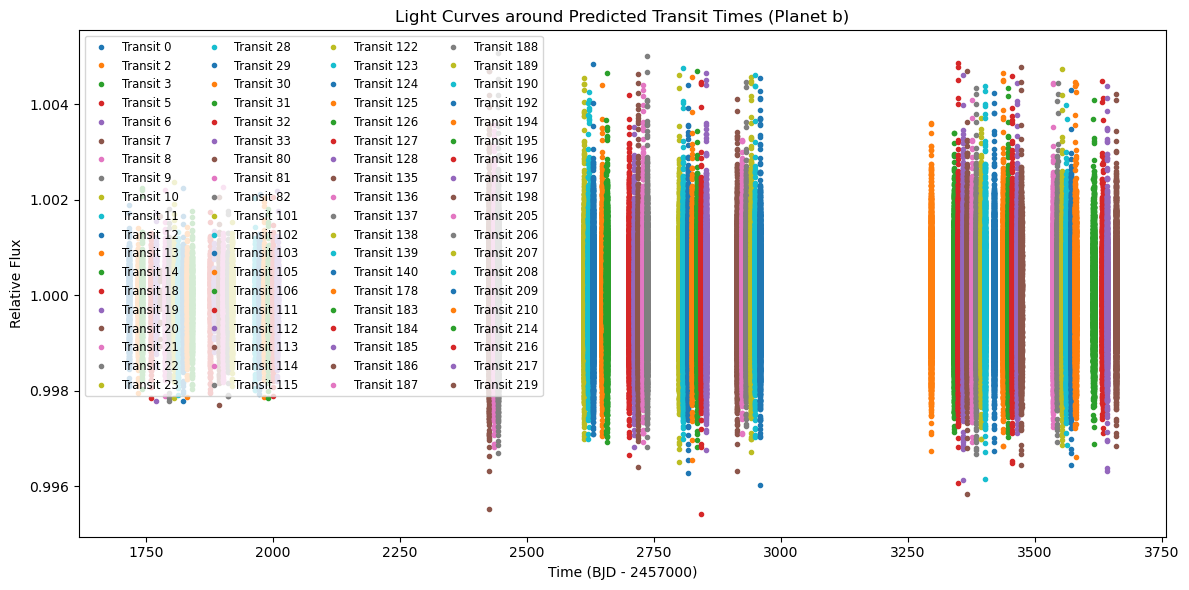

In [72]:
# Plot for planet b
# fig_b, ax_b = plt.subplots(figsize=(12, 6))
# ax_b.set_title('Light Curves around Predicted Transit Times (Planet b)')
# ax_b.set_xlabel('Time (BJD - 2457000)')
# ax_b.set_ylabel('Relative Flux')

# for i, t_pred in enumerate(transit_guess_b):
#     # Select a time window around the predicted transit time
#     mask = (combined_lc.time.value > t_pred - window) & (combined_lc.time.value < t_pred + window)
#     lc_cut = combined_lc[mask]
    
#     if len(lc_cut.time) > 0:
#         ax_b.plot(lc_cut.time.value, lc_cut.flux.value, '.', label=f'Transit {int(indices_b[i])}')
    
# ax_b.legend(fontsize='small', ncol=4)
# plt.tight_layout()
# plt.show()

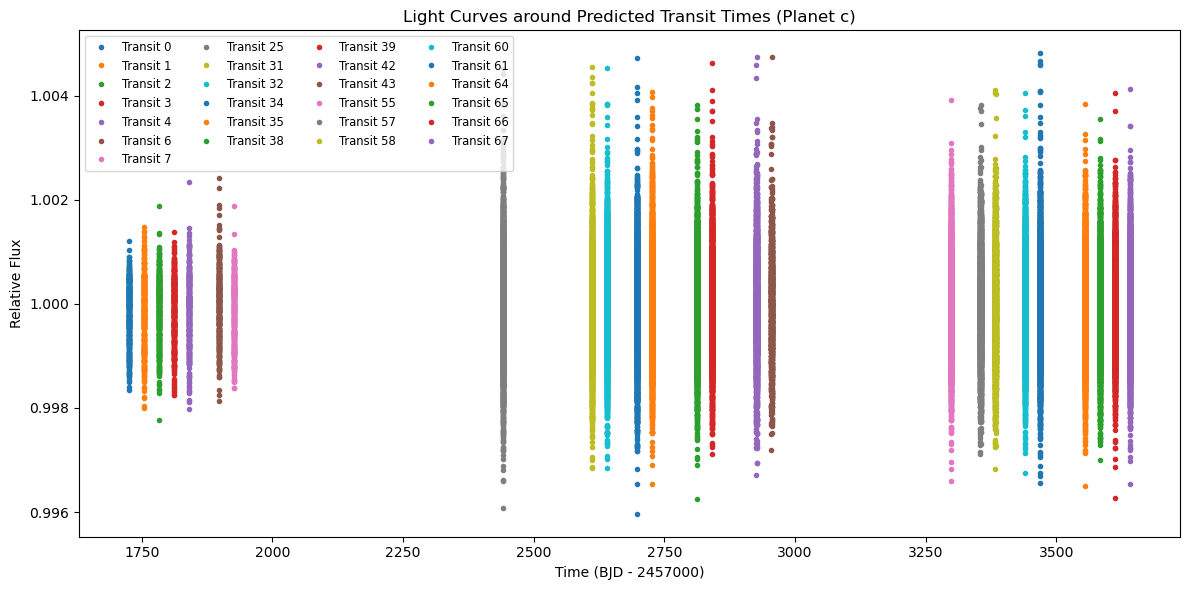

In [73]:
# Plot for planet b
# fig_b, ax_b = plt.subplots(figsize=(12, 6))
# ax_b.set_title('Light Curves around Predicted Transit Times (Planet c)')
# ax_b.set_xlabel('Time (BJD - 2457000)')
# ax_b.set_ylabel('Relative Flux')

# for i, t_pred in enumerate(transit_guess_c):
#     # Select a time window around the predicted transit time
#     mask = (combined_lc.time.value > t_pred - window) & (combined_lc.time.value < t_pred + window)
#     lc_cut = combined_lc[mask]
    
#     if len(lc_cut.time) > 0:
#         ax_b.plot(lc_cut.time.value, lc_cut.flux.value, '.', label=f'Transit {int(indices_c[i])}')
    
# ax_b.legend(fontsize='small', ncol=4)
# plt.tight_layout()
# plt.show()

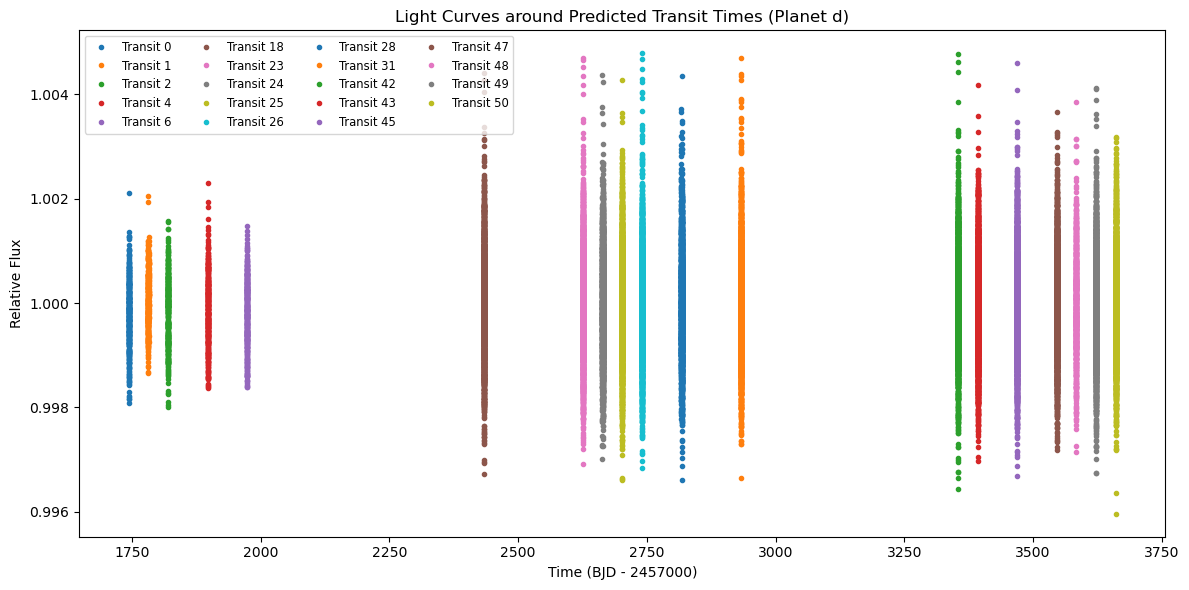

In [74]:
# Plot for planet b
# fig_b, ax_b = plt.subplots(figsize=(12, 6))
# ax_b.set_title('Light Curves around Predicted Transit Times (Planet d)')
# ax_b.set_xlabel('Time (BJD - 2457000)')
# ax_b.set_ylabel('Relative Flux')

# for i, t_pred in enumerate(transit_guess_d):
#     # Select a time window around the predicted transit time
#     mask = (combined_lc.time.value > t_pred - window) & (combined_lc.time.value < t_pred + window)
#     lc_cut = combined_lc[mask]
    
#     if len(lc_cut.time) > 0:
#         ax_b.plot(lc_cut.time.value, lc_cut.flux.value, '.', label=f'Transit {int(indices_d[i])}')
    
# ax_b.legend(fontsize='small', ncol=4)
# plt.tight_layout()
# plt.show()

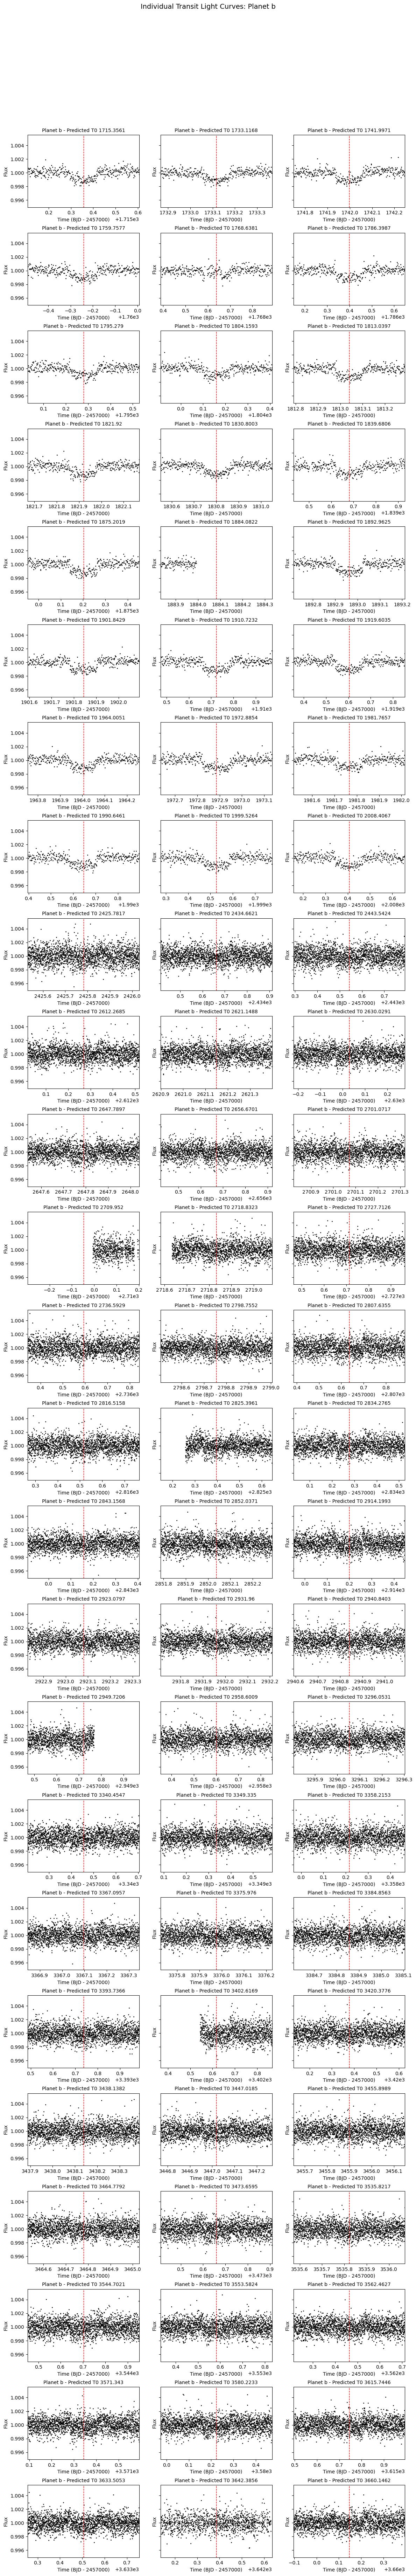

In [75]:
# n_b = len(lc_sections_b)
# cols = 3
# rows = int(np.ceil(n_b / cols))

# fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
# axes = axes.flatten()

# for i, (lc_cut, t_pred, transit_num) in enumerate(lc_sections_b):
#     axes[i].plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)
#     axes[i].axvline(t_pred, color='red', linestyle='--', lw=1)
#     axes[i].set_title(f'Planet b - Predicted T0 {round(t_pred,4)}', fontsize=10)
#     axes[i].set_xlim(t_pred - window, t_pred + window)
#     axes[i].set_xlabel('Time (BJD - 2457000)')
#     axes[i].set_ylabel('Flux')

# # Clean unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# fig.suptitle('Individual Transit Light Curves: Planet b', fontsize=14)
# plt.tight_layout()
# plt.subplots_adjust(top=0.93)
# plt.show()

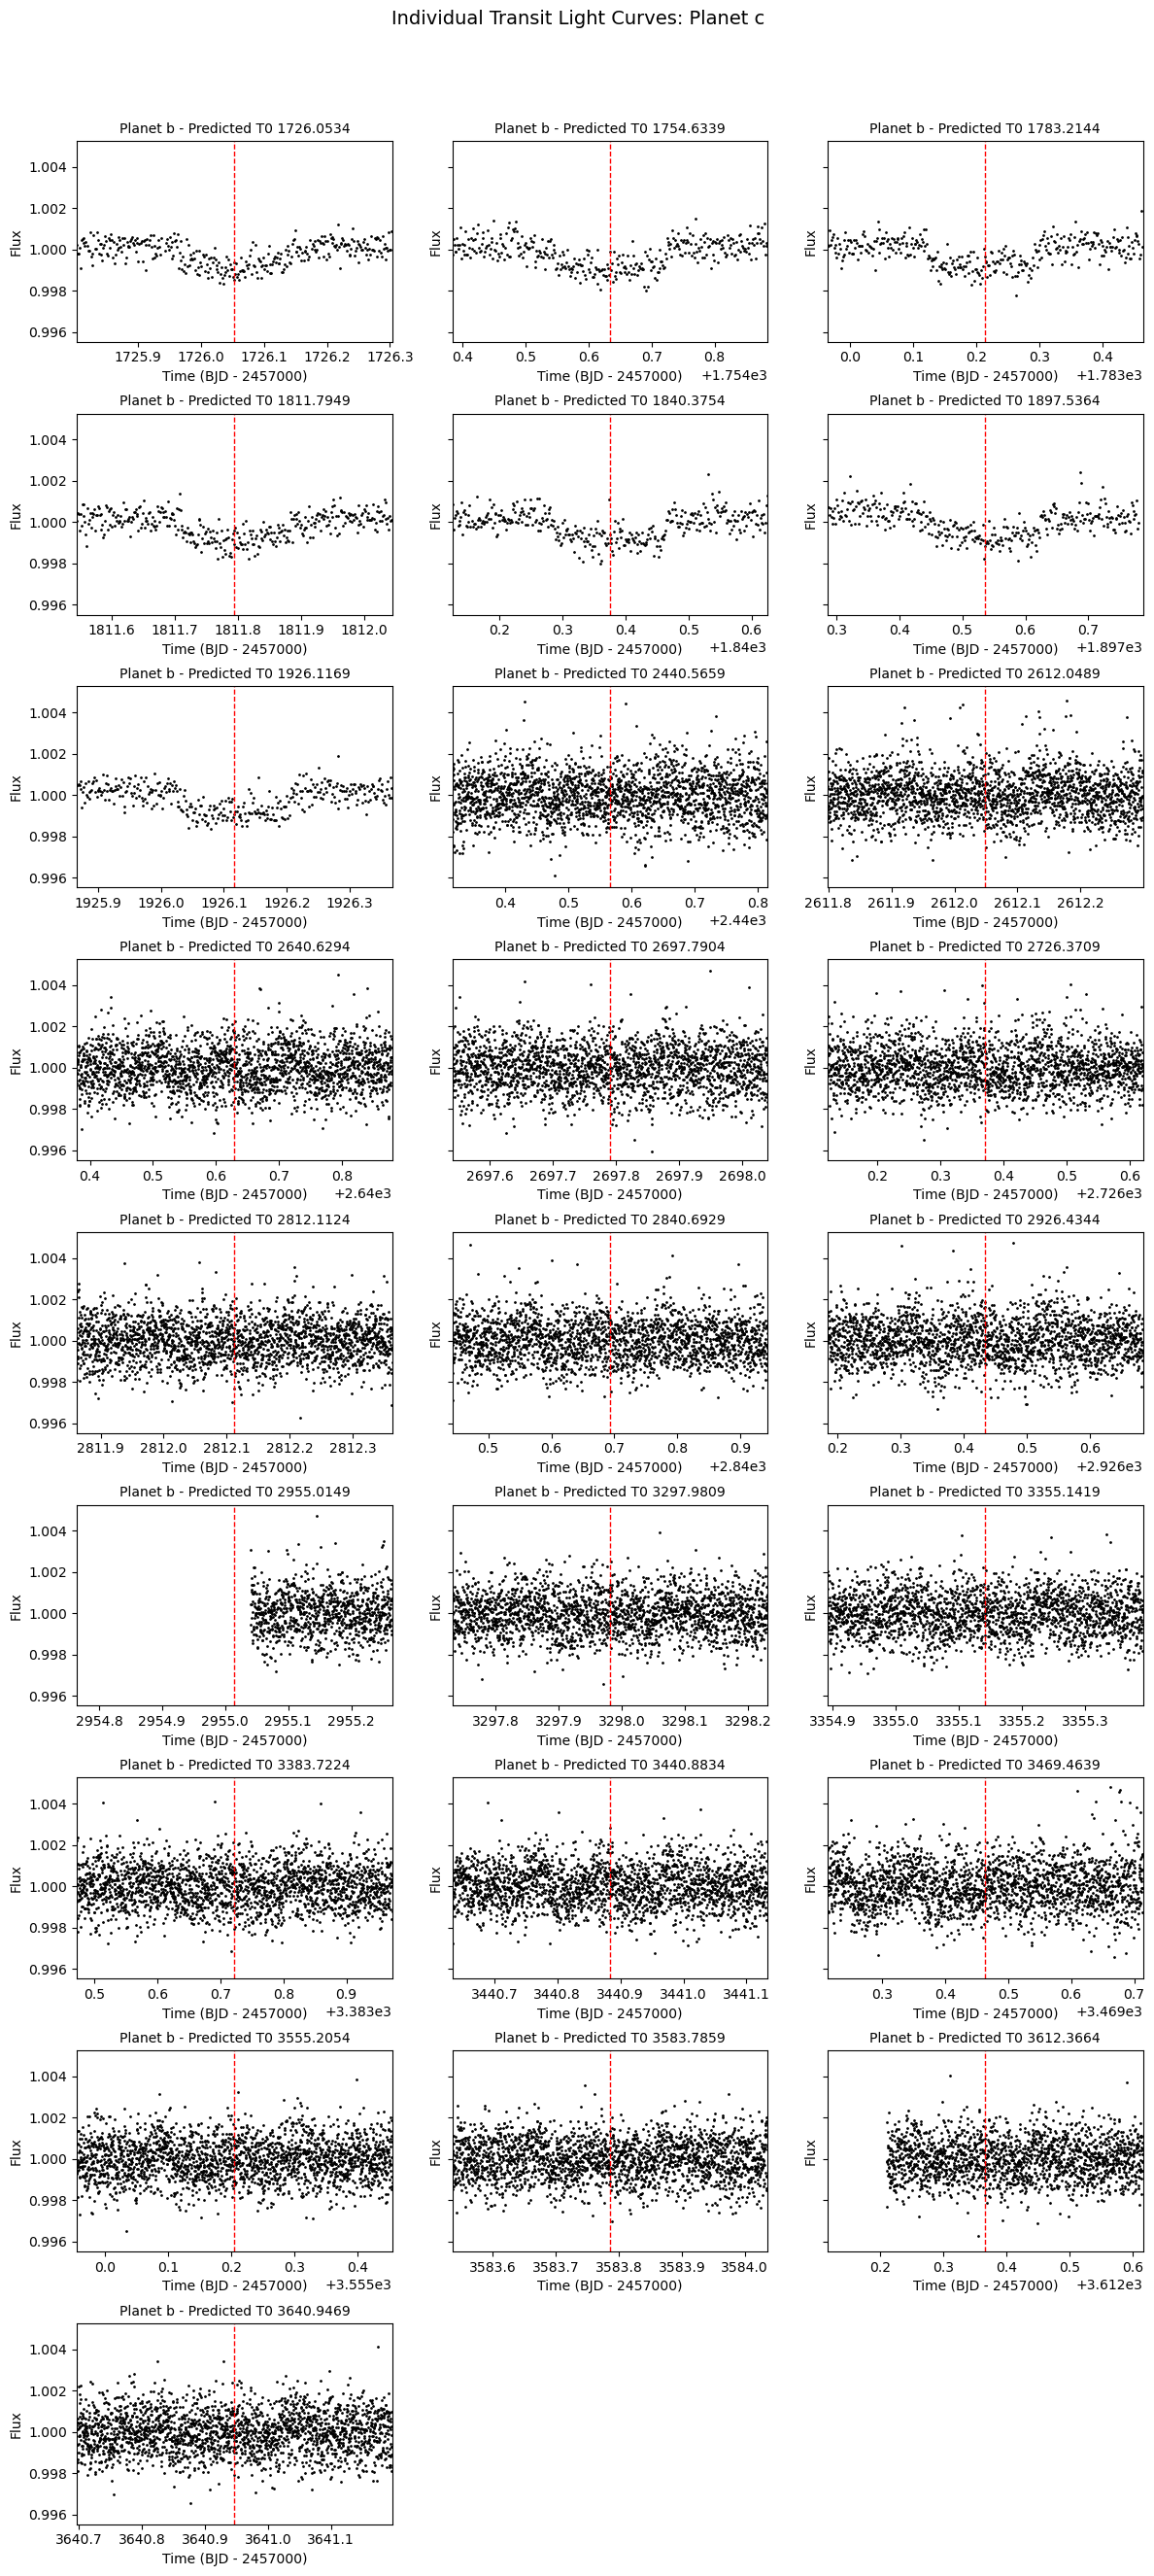

In [76]:
# n_c = len(lc_sections_c)
# cols = 3
# rows = int(np.ceil(n_c / cols))

# fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
# axes = axes.flatten()

# for i, (lc_cut, t_pred, transit_num) in enumerate(lc_sections_c):
#     axes[i].plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)
#     axes[i].axvline(t_pred, color='red', linestyle='--', lw=1)
#     axes[i].set_title(f'Planet b - Predicted T0 {round(t_pred,4)}', fontsize=10)
#     axes[i].set_xlim(t_pred - window, t_pred + window)
#     axes[i].set_xlabel('Time (BJD - 2457000)')
#     axes[i].set_ylabel('Flux')

# # Clean unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# fig.suptitle('Individual Transit Light Curves: Planet c', fontsize=14)
# plt.tight_layout()
# plt.subplots_adjust(top=0.93)
# plt.show()

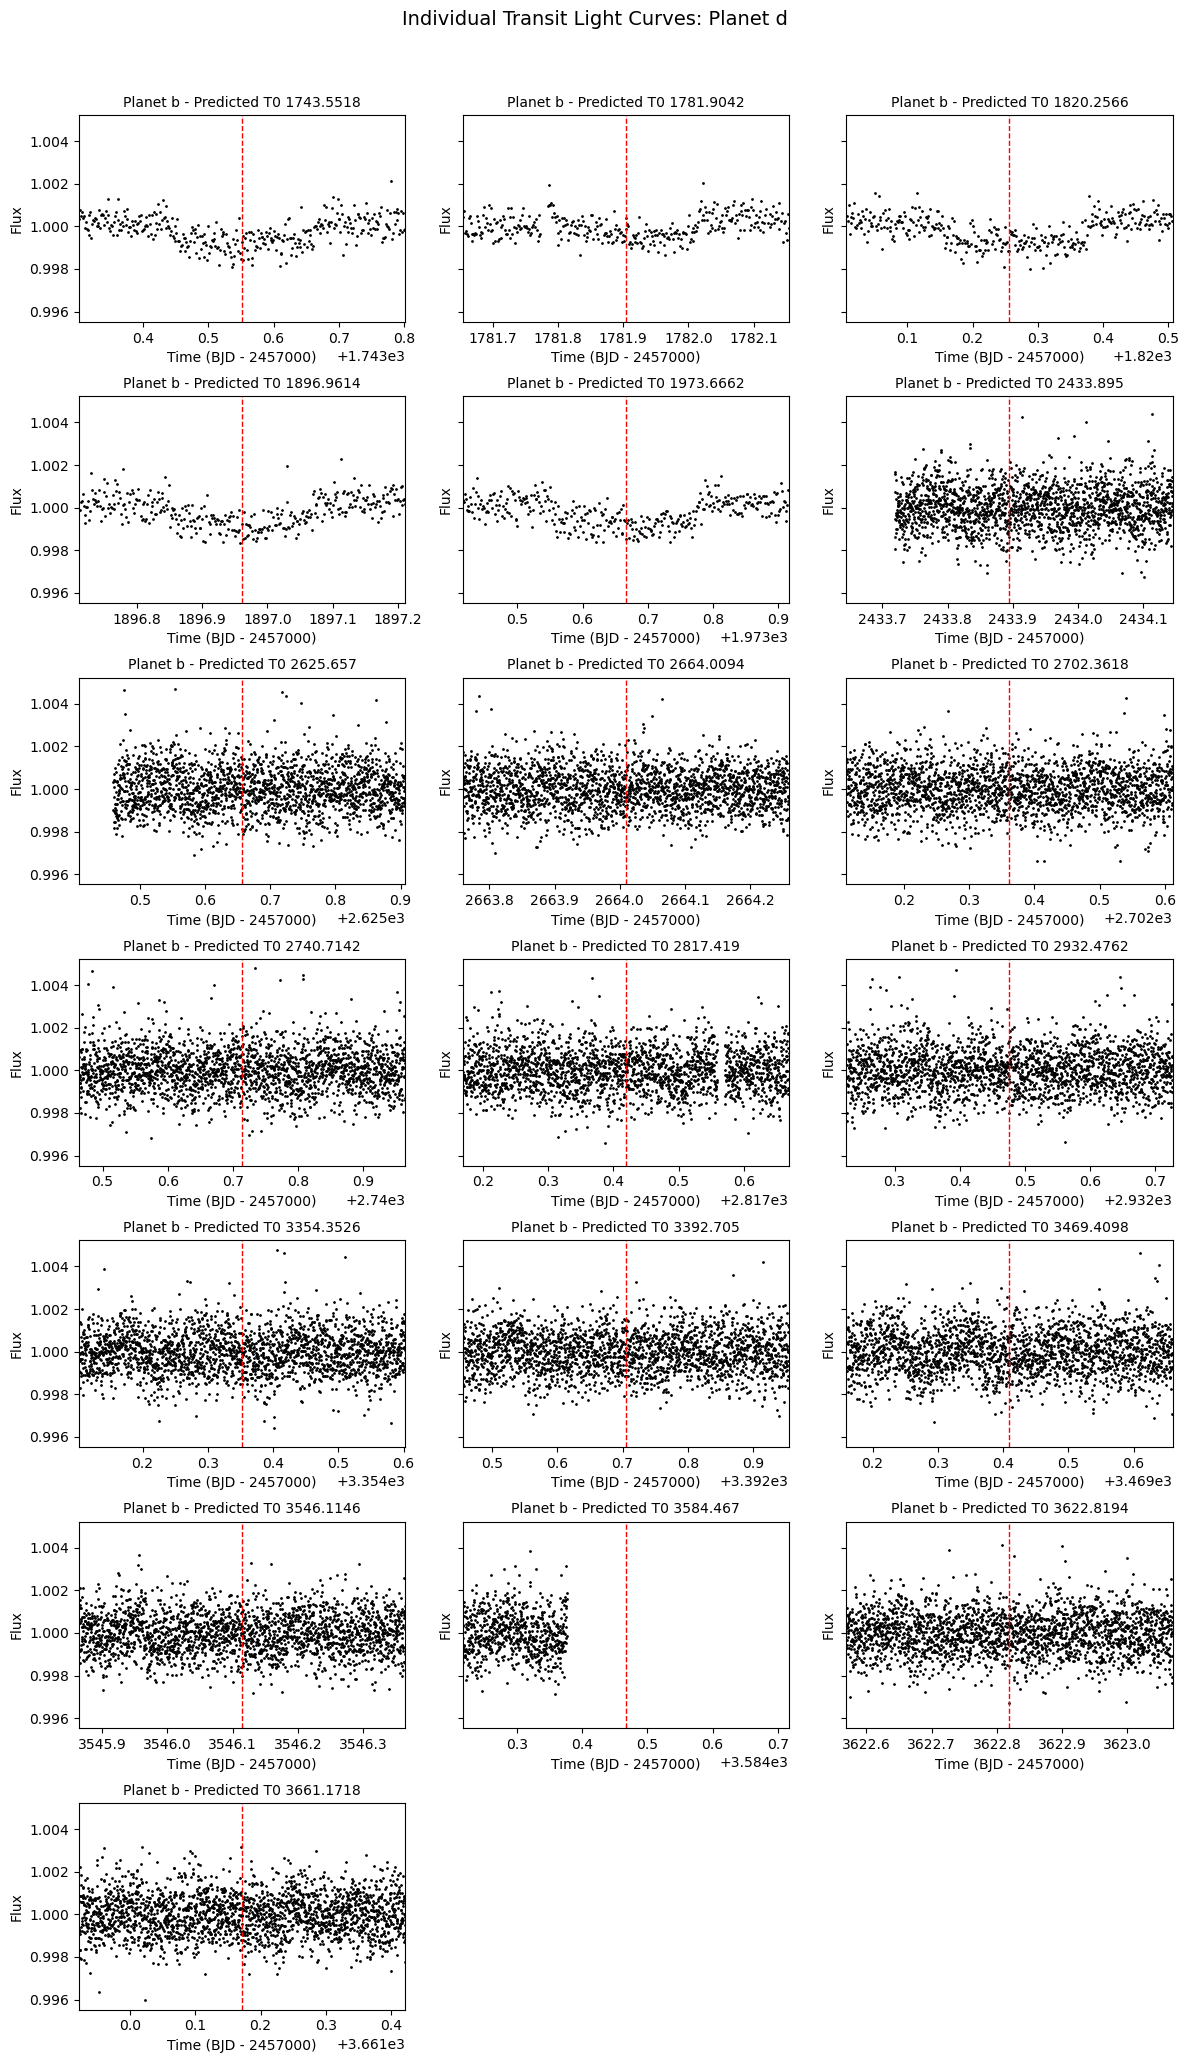

In [77]:
# n_d = len(lc_sections_d)
# cols = 3
# rows = int(np.ceil(n_d / cols))

# fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharey=True)
# axes = axes.flatten()

# for i, (lc_cut, t_pred, transit_num) in enumerate(lc_sections_d):
#     axes[i].plot(lc_cut.time.value, lc_cut.flux.value, 'k.', markersize=2)
#     axes[i].axvline(t_pred, color='red', linestyle='--', lw=1)
#     axes[i].set_title(f'Planet b - Predicted T0 {round(t_pred,4)}', fontsize=10)
#     axes[i].set_xlim(t_pred - window, t_pred + window)
#     axes[i].set_xlabel('Time (BJD - 2457000)')
#     axes[i].set_ylabel('Flux')

# # Clean unused subplots
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# fig.suptitle('Individual Transit Light Curves: Planet d', fontsize=14)
# plt.tight_layout()
# plt.subplots_adjust(top=0.93)
# plt.show()

# Mask out valid transit guesses

In [252]:
# Store detrended, masked individual light curves
detrended_lcs = []

for lc in lc_collection:
    lc_clean = lc.remove_nans()
    times = lc_clean.time.value
    mask = np.zeros_like(times, dtype=bool)

    # Apply transit time masks
    for transit_time in valid_guess_b:
        mask |= (times > (transit_time - (T14_b/2)*1.5)) & (times < (transit_time + (T14_b/2)*1.5))
    for transit_time in valid_guess_c:
        mask |= (times > (transit_time - (T14_c/2)*1.5)) & (times < (transit_time + (T14_c/2)*1.5))
    for transit_time in valid_guess_d:
        mask |= (times > (transit_time - (T14_d/2)*1.5)) & (times < (transit_time + (T14_d/2)*1.5))

    # Choose flattening window size based on cadence
    if lc.meta["EXPOSURE"] < 60:
        window = 1001
    else:
        window = 301

    # window = 1901

    try:
        lc_flat = lc_clean.normalize().flatten(window_length=window, mask=mask).remove_outliers()
        detrended_lcs.append(lc_flat)
    except Exception as e:
        print(f"Skipping one LC due to error: {e}")

# Stitch all masked/detrended LCs
masked_lc = LightCurveCollection(detrended_lcs).stitch()

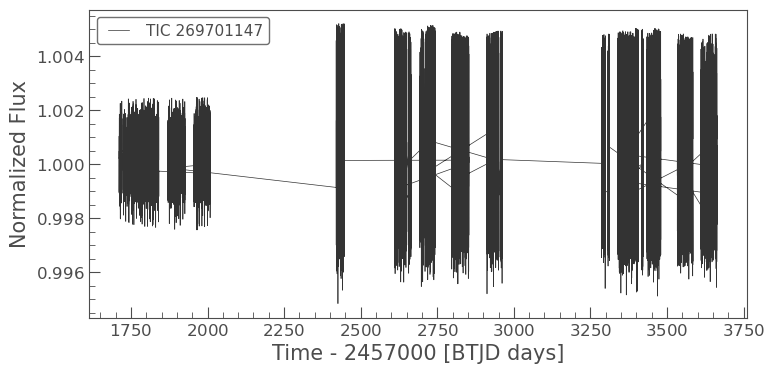

In [253]:
masked_lc.plot()
plt.show()

In [254]:
### data from lightcurve 
time = np.array(masked_lc.time.value)
flux=np.array(masked_lc.flux)
flux_err = np.array(masked_lc.flux_err)


# Fit times

In [255]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

## chisq fit

In [256]:
### Bootstrap method
import numpy as np
import batman
from scipy.optimize import root_scalar
import random

def plot_chi_sq_bootstrap(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2, n_bootstrap=1000):
    '''
    Bootstrap version of plot_chi_sq.

    Args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: list of arrays of trial t0 values for each transit
        tc_guess: list of initial guess times for each transit
        per, rp, b, T14, u1, u2: transit model parameters
        n_bootstrap: number of bootstrap iterations

    Returns:
        tc_chi: list of best-fit t0 values for each transit
        tc_err: list of error estimates (standard deviation) from bootstrap
        tc_samples: list of bootstrap samples of t0 values (for plotting/histogram)
    '''
    tc_chi = []
    tc_err = []
    tc_samples = []

    ttv_hour = 0.5 * T14  # width of window around guess time

    for j in range(len(tc)):
        tc1 = tc[j]
        guess_time = tc_guess[j]

        # Original mask and data
        start = guess_time - ttv_hour
        end = guess_time + ttv_hour
        mask = (time > start) & (time < end)

        time_cut = time[mask]
        flux_cut = flux[mask]
        flux_err_cut = flux_err[mask]

        # Function to compute best-fit tc (min χ²) for a dataset
        def fit_tc(t, f, f_err):
            chi_sq = np.zeros(len(tc1))
            for i in range(len(tc1)):
                t0 = tc1[i]
                params = batman.TransitParams()
                params.t0 = t0
                params.per = per
                params.rp = rp
                params.b = b
                params.T14 = T14
                params.u = [u1, u2]
                params.limb_dark = 'quadratic'

                model = batman.TransitModel(params, t)
                model_flux = model.light_curve(params)
                chi_sq[i] = np.sum(((f - model_flux) / f_err)**2)
            return tc1[np.argmin(chi_sq)]

        # Fit to original data
        best_tc = fit_tc(time_cut, flux_cut, flux_err_cut)
        tc_chi.append(best_tc)

        # Bootstrap resampling
        resampled_tcs = []
        N = len(time_cut)

        for _ in range(n_bootstrap):
            idx = np.random.randint(0, N, N)  # sample with replacement
            time_bs = time_cut[idx]
            flux_bs = flux_cut[idx]
            flux_err_bs = flux_err_cut[idx]
            try:
                resampled_tc = fit_tc(time_bs, flux_bs, flux_err_bs)
                resampled_tcs.append(resampled_tc)
            except:
                continue  # skip failed fits

        resampled_tcs = np.array(resampled_tcs)
        tc_samples.append(resampled_tcs)
        tc_err.append(np.std(resampled_tcs))  # 1-sigma error from bootstrap

    return tc_chi, tc_err, tc_samples


In [257]:
def bootstrap_transit_times(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2, num_bootstrap=100):
    '''
    tc: list of arrays, each array contains a grid of tc values around the guess for each transit
    tc_guess: array of tc guess values, one per transit
    '''
    tc_chi = np.zeros(len(tc))
    ttv = np.zeros(len(tc))
    errors = []

    for j in range(len(tc)):
        tc_grid = tc[j]  # fine grid of tc values around guess for this transit
        tc_samples = []

        for _ in range(num_bootstrap):
            # Bootstrap resample the data within the relevant time window
            start = tc_guess[j] - ttv_window
            end = tc_guess[j] + ttv_window
            mask = (time > start) & (time < end)

            time_boot = time[mask]
            flux_boot = flux[mask]
            flux_err_boot = flux_err[mask]

            # Resample with replacement
            resample_idx = np.random.choice(len(time_boot), size=len(time_boot), replace=True)
            time_sample = time_boot[resample_idx]
            flux_sample = flux_boot[resample_idx]
            flux_err_sample = flux_err_boot[resample_idx]

            chi_sq = np.zeros(len(tc_grid))

            for i, t0 in enumerate(tc_grid):
                params = batman.TransitParams()
                params.t0 = t0
                params.per = per
                params.rp = rp
                params.b = b
                params.T14 = T14
                params.u = [u1, u2]
                params.limb_dark = "quadratic"

                try:
                    model = batman.TransitModel(params, time_sample)
                    model_flux = model.light_curve(params)
                    chi_sq[i] = np.sum(((flux_sample - model_flux) / flux_err_sample)**2)
                except RuntimeError:
                    chi_sq[i] = np.inf  # If model fails, mark as bad

            best_tc = tc_grid[np.argmin(chi_sq)]
            tc_samples.append(best_tc)

        tc_samples = np.array(tc_samples)
        median_tc = np.median(tc_samples)
        tc_chi[j] = median_tc
        ttv[j] = median_tc - tc_guess[j]
        err_lo = np.percentile(tc_samples, 16) - median_tc
        err_hi = np.percentile(tc_samples, 84) - median_tc
        errors.append((abs(err_lo), abs(err_hi)))

    return tc_chi, ttv, errors


## Single Transits

In [258]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(time, flux, flux_err, transit_times, per, rp, b, T14, u1, u2, buffer = 0.1, offset=tess_offset):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


## Folded transits

In [295]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []
    all_flux_err = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])
        all_flux_err.append(flux_err[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)
    folded_flux_err = np.concatenate(all_flux_err)

    # Sort by phase
    sort_idx = np.argsort(folded_phase)
    folded_phase = folded_phase[sort_idx]
    folded_flux = folded_flux[sort_idx]
    folded_flux_err = folded_flux_err[sort_idx]

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return folded_phase, folded_flux, folded_flux_err

## Params

In [260]:
from astropy.constants import G, M_sun, R_sun
import astropy.units as u


def semi_major_axis(P, M_star, R_star):
    '''
    P: period in days
    M_star: stellar mass in M_sun
    R_star: stellar radius in R_sun
    '''
    P_ = P * u.day
    M_star_ = M_star * M_sun
    R_star_ = R_star * R_sun
    a = ((G*M_star_*P_**2) / (4*np.pi**2))**(1./3.)
    a_stellar_radii = (a / R_star_).decompose()
    return a_stellar_radii.value

In [261]:
### stellar params
# q1 = 0.304
# q2 = 0.40

# u1 = 2 * np.sqrt(q1) * q2
# u2 = np.sqrt(q1) * (1 - 2 * q2)

# from LDTk
u1 = 0.4422 #± 0.0018
u2 = 0.1470 #± 0.0029
print(u1)
print(u2)

0.4422
0.147


In [262]:
### planet params from lubin 2022
per_b = 8.88029
rp_b = 0.0336
b_b = 0.62 # lubin 2022
T14_b = 3.1 * 0.0416667

per_c = 28.5805
rp_c = 0.0306
b_c = 0.630
T14_c = 4.5 * 0.0416667

per_d = 38.3525
rp_d = 0.0302
b_d = 0.48
T14_d = 5.5 * 0.0416667

## Planet b

In [263]:
### initialize arrays
tc_chi = np.zeros(len(valid_guess_b))
tc_chi_parabola = np.zeros(len(valid_guess_b))
errors = []
err_tc_chi = []

In [264]:
### get tc ranges for fit
ttv_window = 0.5
tc_b = []
for i in range(len(valid_guess_b)):
    start = valid_guess_b[i] - ttv_window
    end = valid_guess_b[i] + ttv_window
    t = np.linspace(start,end, 1000)
    tc_b.append(t)

In [265]:
tc_chi_b, ttv_b, tc_err_b = bootstrap_transit_times(time, flux, flux_err,
                                                    tc_b, valid_guess_b,
                                                    per_b, rp_b, b_b, T14_b, u1, u2)

In [266]:
# tc_chi_b, tc_err_b, tc_samples_b = plot_chi_sq_bootstrap(time, flux, flux_err, tc_b, valid_guess_b, per_b, rp_b, b_b, T14_b, u1, u2)

In [267]:
print(tc_chi_b)
print(tc_err_b)

[1715.3546315  1733.1152715  1741.9965925  1759.7592345  1768.6375525
 1786.3991935  1795.2825165  1804.1588325  1813.0421555  1821.9184715
 1830.8017945  1839.6811135  1875.2013925  1884.05768848 1892.9630335
 1901.8433535  1910.7216715  1919.6019915  1964.0035915  1972.8839115
 1981.7652325  1990.6445515  1999.5248715  2008.4051915  2425.7812325
 2434.6625535  2443.5428735  2612.2679525  2621.1512755  2630.0275915
 2647.7892325  2656.6695525  2701.0721535  2709.9504715  2718.8327935
 2727.7121125  2736.5924325  2798.7536715  2807.6349925  2816.5143115
 2825.3956325  2834.2769535  2843.1572735  2852.0375935  2914.1968305
 2923.0781515  2931.9574705  2940.8397925  2949.7201125  2958.6014335
 3296.0505905  3340.4541925  3349.3345125  3358.2128305  3367.096654
 3375.9754725  3384.8537905  3393.7381145  3402.6174335  3420.3760715
 3438.1367115  3447.0180325  3455.8993535  3464.7786725  3473.6619955
 3535.8242355  3544.7005515  3553.5828735  3562.4621925  3571.3445145
 3580.2228325  3615.7

In [268]:
import math
### after inspection of single transits
values_to_remove_b = [1884.052, 2612.028148, 2709.95157559]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_b_cleaned = []
ttv_b_cleaned = []
tc_err_b_cleaned = []

for i in range(len(tc_chi_b)):
    if not any(math.isclose(tc_chi_b[i], val, abs_tol=tolerance) for val in values_to_remove_b):
        tc_chi_b_cleaned.append(tc_chi_b[i])
        ttv_b_cleaned.append(ttv_b[i])
        tc_err_b_cleaned.append(tc_err_b[i])

# Overwrite the originals if needed
tc_chi_b = tc_chi_b_cleaned
ttv_b = ttv_b_cleaned
tc_err_b = tc_err_b_cleaned
print("Modified List (after removal):", tc_chi_b)
# print(tc_err1)


Modified List (after removal): [1715.3546314984924, 1733.1152714984923, 1741.9965924994933, 1759.7592345014953, 1768.6375524994933, 1786.3991935004944, 1795.2825165034974, 1804.1588324994934, 1813.0421555024964, 1821.9184714984924, 1830.8017945014954, 1839.6811135004943, 1875.2013924994933, 1892.9630335004942, 1901.8433535004942, 1910.7216714984925, 1919.6019914984925, 1964.0035914984924, 1972.8839114984924, 1981.7652324994933, 1990.6445514984923, 1999.5248714984923, 2008.4051914984923, 2425.7812324994934, 2434.662553500494, 2443.5428735004944, 2621.151275502496, 2630.0275914984923, 2647.789232499493, 2656.6695524994934, 2701.072153500494, 2718.8327935004945, 2727.7121124994933, 2736.592432499493, 2798.7536714984926, 2807.6349924994934, 2816.514311498492, 2825.3956324994933, 2834.2769535004945, 2843.1572735004943, 2852.037593500494, 2914.196830497491, 2923.0781514984924, 2931.957470497491, 2940.8397924994933, 2949.7201124994936, 2958.6014335004943, 3296.0505904974916, 3340.454192499493

In [269]:
tc_err_b_comb = []
for i in range(len(tc_err_b)):
    if len(tc_err_b[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err_b[i][0]**2 + tc_err_b[i][1]**2)
        tc_err_b_comb.append(sig)
    else:
        print(f"Unexpected format in tc_errb[{i}]: {tc_errb_comb[i]}, {tc_chi_b[i]}")


In [270]:
# Transit windows
buffer = 1.5 * T14_b


In [313]:
# time= np.array(time)
# tc_chi_b = np.array(tc_chi_b)
# plot_transits(time, flux, flux_err, 
#               tc_chi_b, 
#               per_b, rp_b, b_b, T14_b, u1, u2, 
#               buffer=T14_b*1.5, 
#               offset=tess_offset)

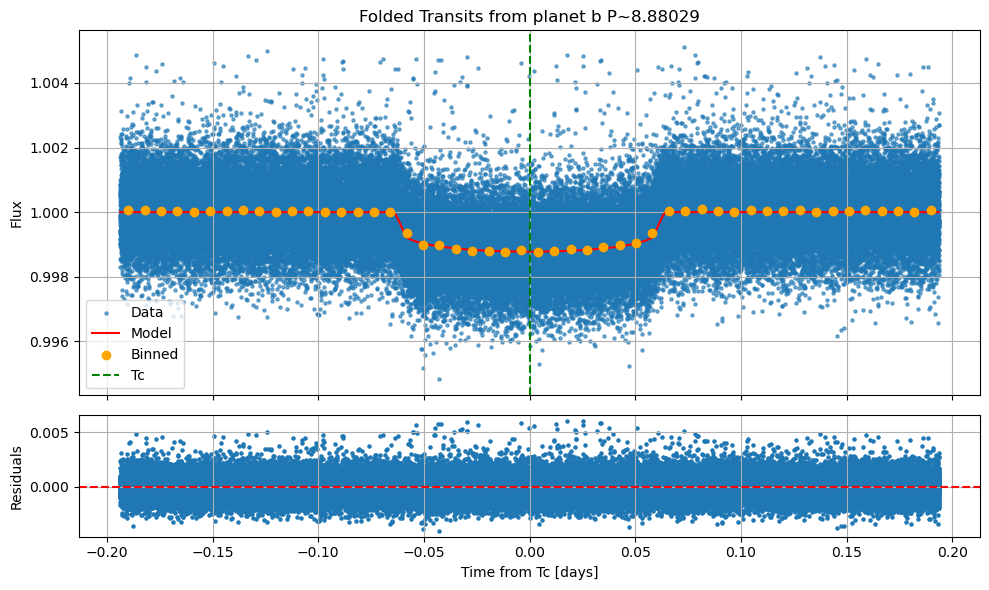

In [296]:
time= np.array(time)
tc_chi_b = np.array(tc_chi_b)
folded_phase_b, folded_flux_b, folded_flux_err_b = plot_folded_from_transits(tc_chi_b, time, flux, 
                                                                             per_b, rp_b, b_b, T14_b, u1, u2, 
                                                                             buffer=T14_b*1.5,
                                                                             title=f'Folded Transits from planet b P~{per_b}')

In [311]:
from scipy.optimize import minimize
# Define chi^2 function
def transit_chi2(theta, phase, flux, flux_err):
    rp, b, T14 = theta
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per_b
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'
    
    model = batman.TransitModel(params, phase)
    model_flux = model.light_curve(params)
    
    chi2 = np.sum(((flux - model_flux)/flux_err)**2)
    return chi2

# Initial guess
theta0 = [rp_b, b_b, T14_b]  # rp, b, T14
res = minimize(transit_chi2, theta0, args=(folded_phase_b, folded_flux_b, folded_flux_err_b))

best_rp_b, best_b_b, best_T14_b = res.x
print("Initial guess:", rp_b, b_b, T14_b, T14_b/0.0416667)
print("Best-fit parameters:", best_rp_b, best_b_b, best_T14_b, best_T14_b/0.0416667)

Initial guess: 0.0336 0.62 0.12916677000000001 3.1
Best-fit parameters: 0.033360257118350625 0.5785530087481424 0.12776661125971545 3.066396217116197


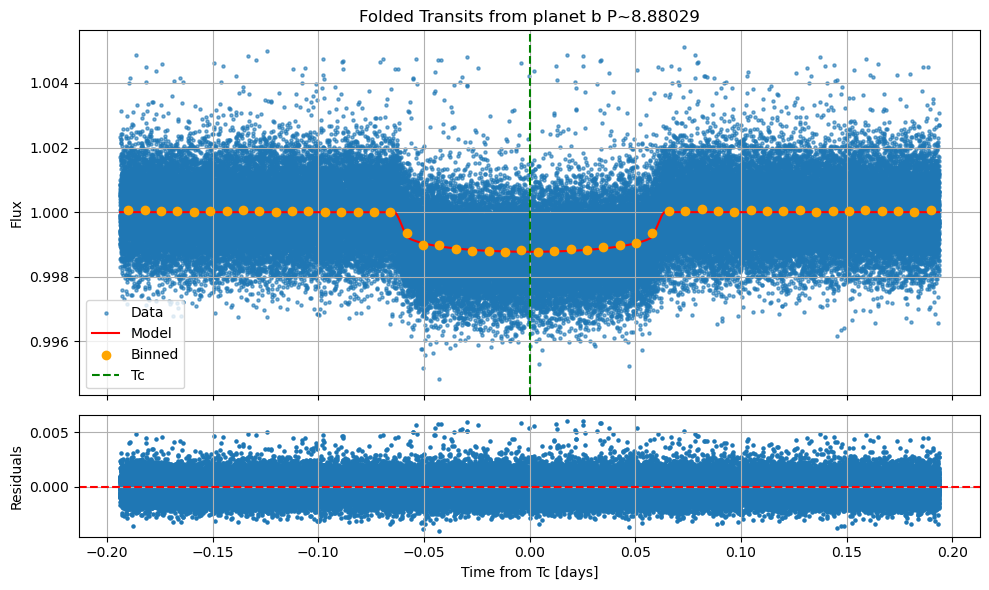

In [300]:
folded_phase_b, folded_flux_b, folded_flux_err_b = plot_folded_from_transits(tc_chi_b, time, flux, 
                                                                             per_b, best_rp_b, best_b_b, best_T14_b, u1, u2, 
                                                                             buffer=T14_b*1.5,
                                                                             title=f'Folded Transits from planet b P~{per_b}')

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_13686/3964640797.py:40: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
/opt/homebrew/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


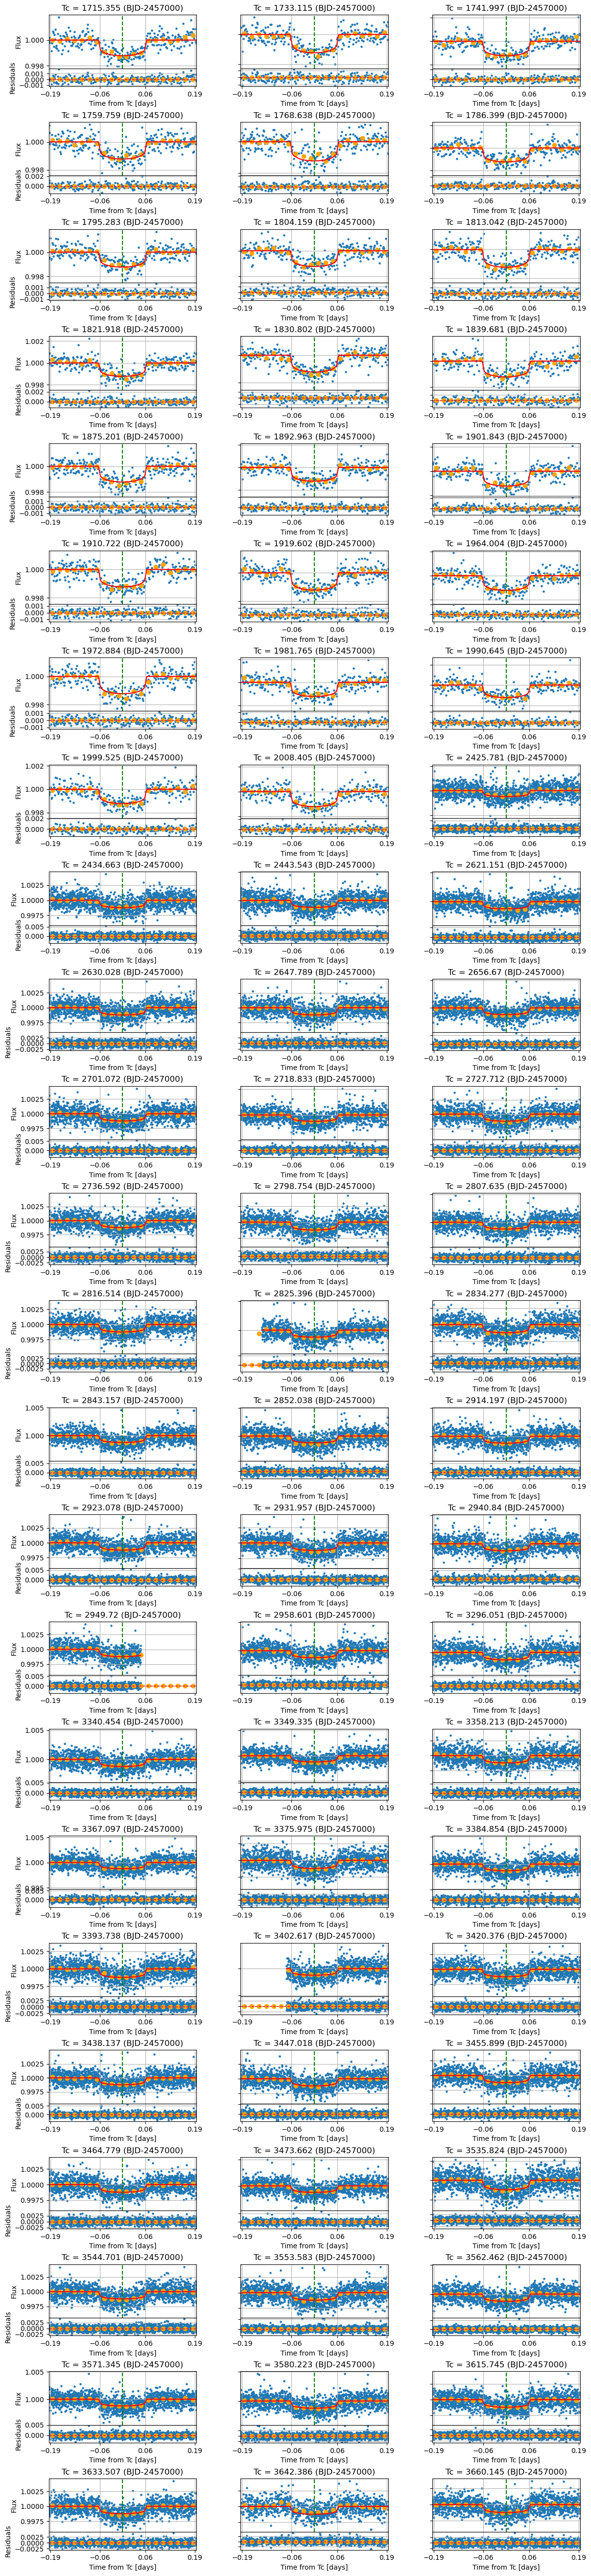

In [314]:
time= np.array(time)
tc_chi_b = np.array(tc_chi_b)
plot_transits(time, flux, flux_err, 
              tc_chi_b, 
              per_b, best_rp_b, best_b_b, best_T14_b, u1, u2, 
              buffer=T14_b*1.5, 
              offset=tess_offset)

In [273]:
print(len(tc_chi_b))

72


## Planet c

In [274]:
### initialize arrays
tc_chi = np.zeros(len(valid_guess_c))
tc_chi_parabola = np.zeros(len(valid_guess_c))
errors = []
err_tc_chi = []

In [275]:
### get tc ranges for fit
ttv_window = 0.5
tc_c = []
for i in range(len(valid_guess_c)):
    start = valid_guess_c[i] - ttv_window
    end = valid_guess_c[i] + ttv_window
    t = np.linspace(start,end, 1000)
    tc_c.append(t)

In [276]:
tc_chi_c, ttv_c, tc_err_c = bootstrap_transit_times(time, flux, flux_err,
                                                    tc_c, valid_guess_c,
                                                    per_c, rp_c, b_c, T14_c, u1, u2)

In [277]:
print(tc_chi_c)
print(tc_err_c)

[1726.0548675  1754.6333655  1783.2118635  1811.7993705  1840.3748655
 1897.5358655  1926.1163655  2440.54534548 2612.03034748 2640.60684348
 2697.77184748 2726.35334848 2812.09584948 2840.67334648 2926.41985149
 2955.00335449 3297.97035549 3355.12935349 3383.71085449 3440.87685949
 3469.41832045 3555.19485549 3583.77235249 3612.34984948 3640.93185098]
[(0.0030030030029593036, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010009864345), (0.002002002001972869, 0.0010010010009864345), (0.0, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010009864345), (0.0010010010009864345, 0.002002002001972869), (0.002002002001972869, 0.0), (0.0030030030029593036, 0.04240240240278581), (0.0010010010009864345, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010009864345), (0.002002002001972869, 0.0020020020024276164), (0.0031631631632080826, 0.0020020020024276164), (0.0010010010009864345, 0.0010010010009864345), (0.00100100100

In [278]:
### after inspection of single transits
values_to_remove_c = [2612.028148, 2954.99879838, 3469.42643231]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_2 = [x for x in tc_chi_2 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_2)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_c_cleaned = []
ttv_c_cleaned = []
tc_err_c_cleaned = []

for i in range(len(tc_chi_c)):
    if not any(math.isclose(tc_chi_c[i], val, abs_tol=tolerance) for val in values_to_remove_c):
        tc_chi_c_cleaned.append(tc_chi_c[i])
        ttv_c_cleaned.append(ttv_c[i])
        tc_err_c_cleaned.append(tc_err_c[i])

# Overwrite the originals if needed
tc_chi_c = tc_chi_c_cleaned
ttv_c = ttv_c_cleaned
tc_err_c = tc_err_c_cleaned
print("Modified List (after removal):", tc_chi_c)


Modified List (after removal): [1726.0548675013342, 1754.6333654993323, 1783.2118634973303, 1811.7993705043373, 1840.3748654993324, 1897.5358654993322, 1926.1163654993322, 2440.545345479312, 2640.60684347731, 2697.771847481314, 2726.353348482315, 2812.095849483316, 2840.6733464803133, 2926.4198514853188, 3297.970355489322, 3355.1293534873203, 3383.7108544883213, 3440.8768594933263, 3555.1948554893224, 3583.7723524863195, 3612.349849483316, 3640.931850984818]


In [279]:
tc_err_c_comb = []
for i in range(len(tc_err_c)):
    if len(tc_err_c[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err_c[i][0]**2 + tc_err_c[i][1]**2)
        tc_err_c_comb.append(sig)
    else:
        print(f"Unexpected format in tc_err_c[{i}]: {tc_err_c_comb[i]}, {tc_chi_c[i]}")


In [315]:
# time= np.array(time)
# tc_chi_c = np.array(tc_chi_c)
# plot_transits(time, flux, flux_err, 
#               tc_chi_c, 
#               per_c, rp_c, b_c, T14_c, u1, u2, 
#               buffer=T14_c*1.5, 
#               offset=tess_offset)

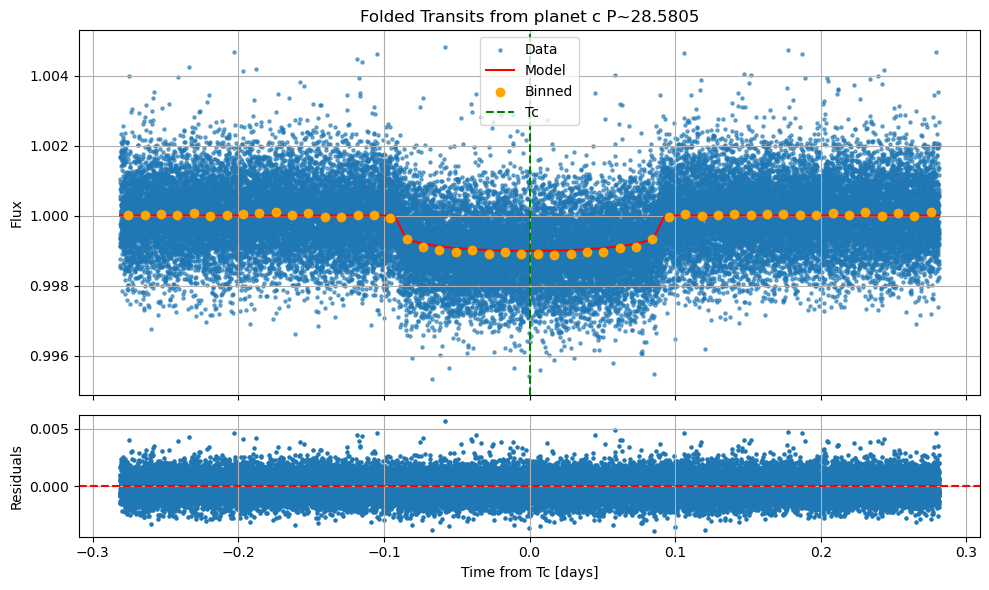

In [302]:
time= np.array(time)
tc_chi_c = np.array(tc_chi_c)
folded_phase_c, folded_flux_c, folded_flux_err_c = plot_folded_from_transits(tc_chi_c, time, flux, 
                                                                             per_c, rp_c, b_c, T14_c, u1, u2, 
                                                                             buffer=T14_c*1.5,
                                                                             title=f'Folded Transits from planet c P~{per_c}')

In [310]:
# Initial guess
theta0 = [rp_c, b_c, T14_c]  # rp, b, T14
res = minimize(transit_chi2, theta0, args=(folded_phase_c, folded_flux_c, folded_flux_err_c))

best_rp_c, best_b_c, best_T14_c = res.x
print("Initial guess:", rp_c, b_c, T14_c, T14_c/0.0416667)
print("Best-fit parameters:", best_rp_c, best_b_c, best_T14_c, best_T14_c/0.0416667)

Initial guess: 0.0306 0.63 0.18750015 4.5
Best-fit parameters: 0.0308490012275386 0.43268422777139676 0.18616600010536763 4.467980428144481


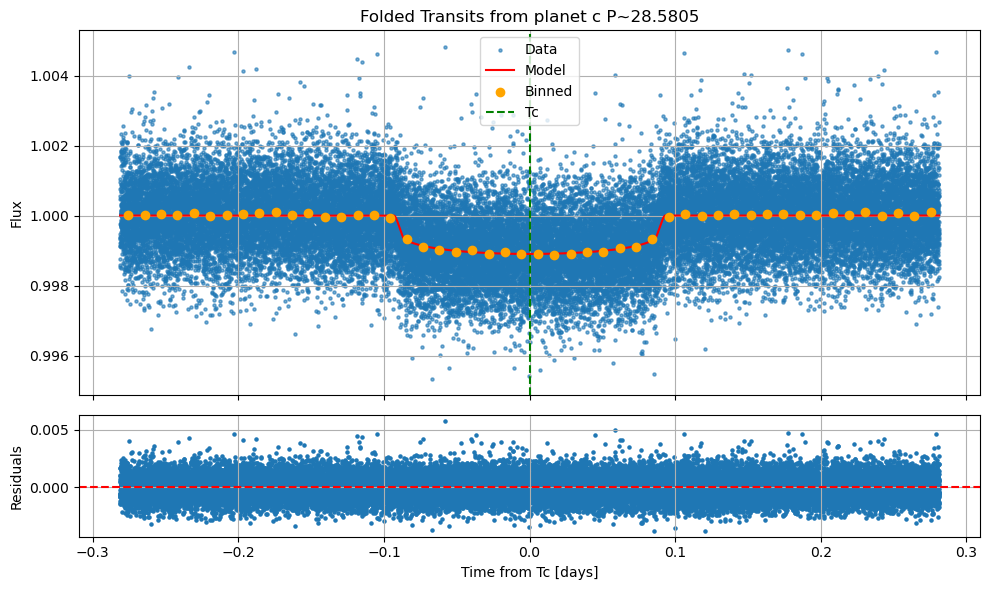

In [305]:
time= np.array(time)
tc_chi_c = np.array(tc_chi_c)
folded_phase_c, folded_flux_c, folded_flux_err_c = plot_folded_from_transits(tc_chi_c, time, flux, 
                                                                             per_c, best_rp_c, best_b_c, best_T14_c, u1, u2, 
                                                                             buffer=T14_c*1.5,
                                                                             title=f'Folded Transits from planet c P~{per_c}')

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_13686/3964640797.py:40: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]


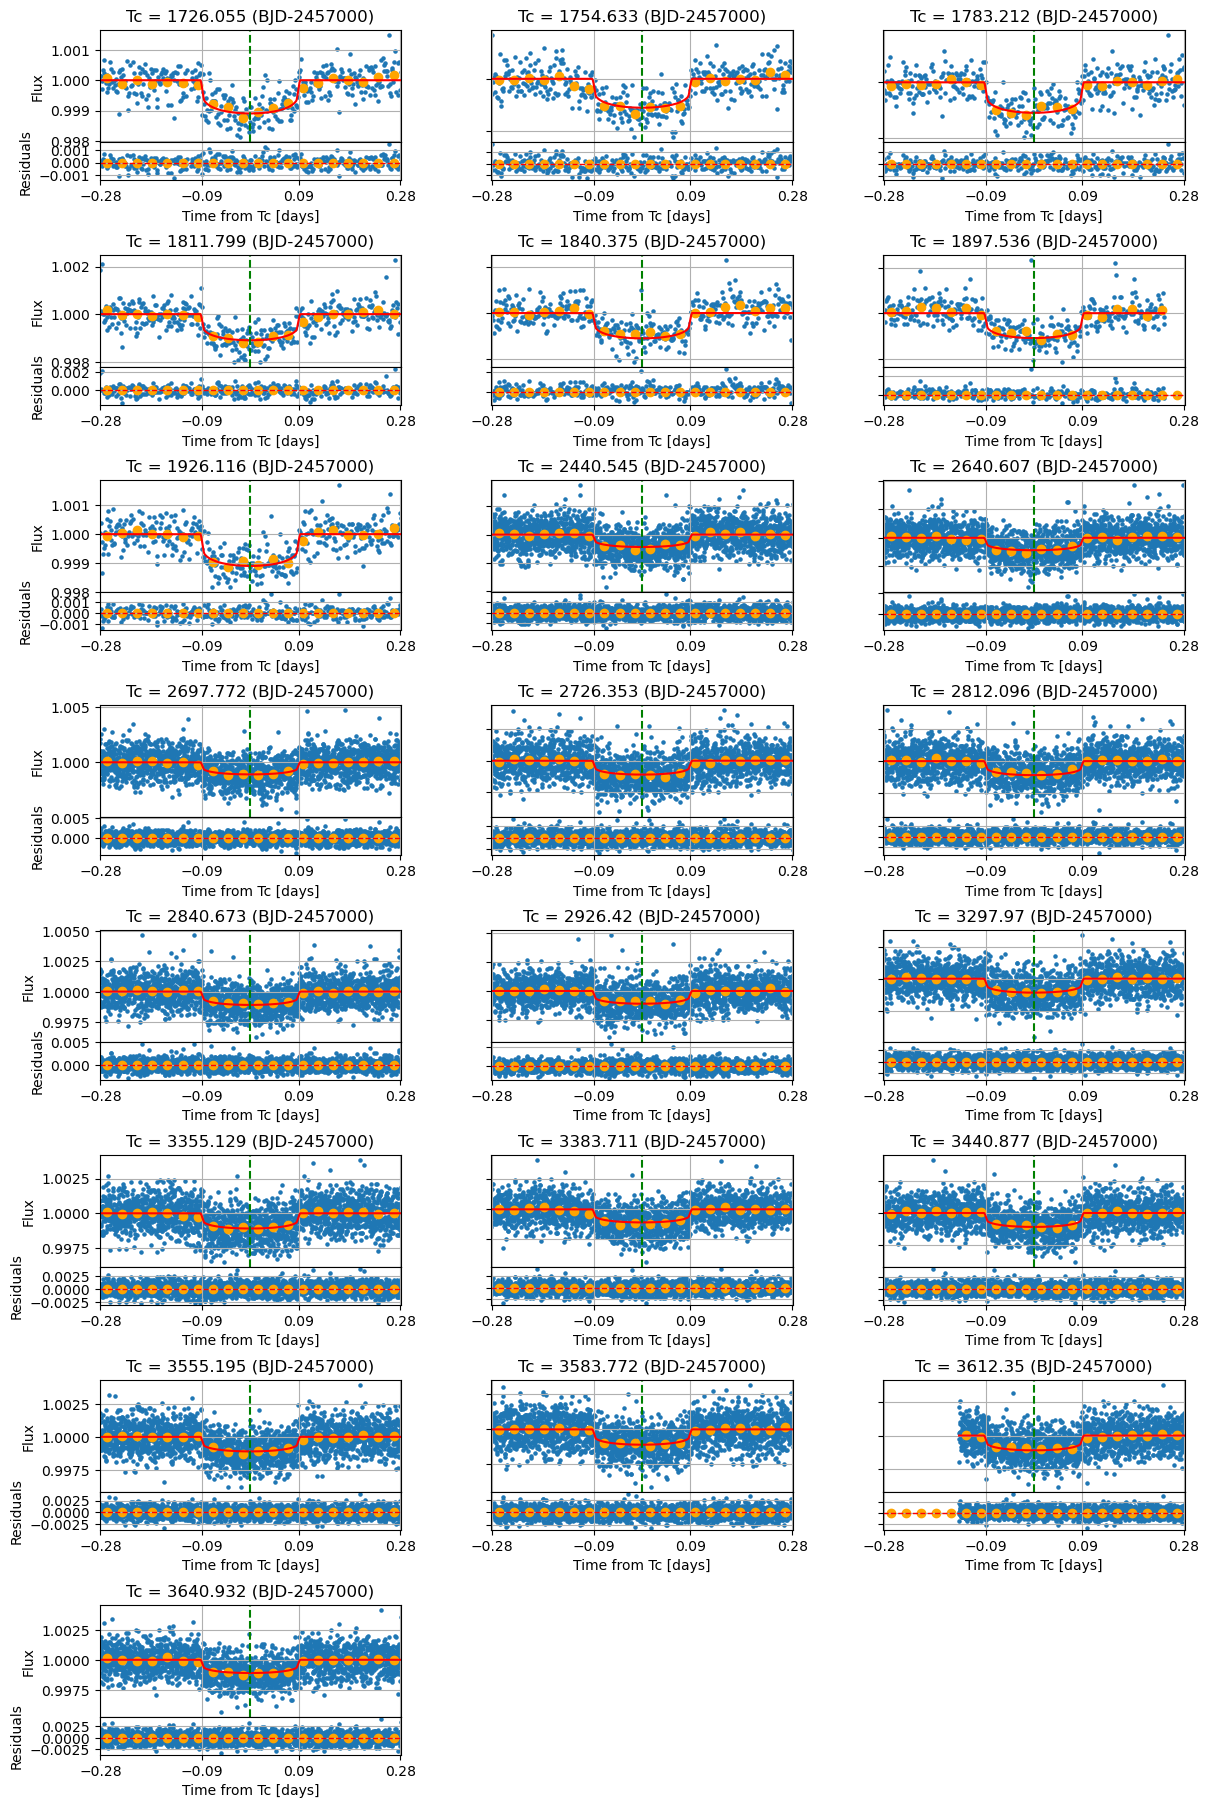

In [316]:
time= np.array(time)
tc_chi_c = np.array(tc_chi_c)
plot_transits(time, flux, flux_err, 
              tc_chi_c, 
              per_c, best_rp_c, best_b_c, best_T14_c, u1, u2, 
              buffer=T14_c*1.5, 
              offset=tess_offset)

In [282]:
print(len(tc_chi_c))

22


## Planet d

In [283]:
### initialize arrays
tc_chi = np.zeros(len(valid_guess_d))
tc_chi_parabola = np.zeros(len(valid_guess_d))
errors = []
err_tc_chi = []

In [284]:
### get tc ranges for fit
ttv_window = 0.5
tc_d = []
for i in range(len(valid_guess_d)):
    start = valid_guess_d[i] - ttv_window
    end = valid_guess_d[i] + ttv_window
    t = np.linspace(start,end, 1000)
    tc_d.append(t)

In [285]:
tc_chi_d, ttv_d, tc_err_d = bootstrap_transit_times(time, flux, flux_err,
                                                    tc_d, valid_guess_d,
                                                    per_d, rp_d, b_d, T14_d, u1, u2)

In [286]:
print(tc_chi_d)
print(tc_err_d)

[1743.5532885  1781.9036865  1820.26509551 1896.9618875  1973.6646855
 2433.91750952 2625.67250252 2664.02490252 2702.35277799 2740.7176905
 2817.41147949 2932.46267349 3354.30303745 3392.66044246 3469.41479201
 3546.07404646 3584.42144145 3622.76983745 3661.12674196]
[(0.002002002001972869, 0.0010010010009864345), (0.0010010010009864345, 0.0), (0.0010010010012138082, 0.002002002001972869), (0.002002002001972869, 0.0030030030029593036), (0.0010010010009864345, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010014411819), (0.0011611611612352135, 0.0020020020024276164), (0.0015015015014796518, 0.003503503503452521), (0.002002002001972869, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010009864345), (0.0, 0.0010010010009864345), (0.002002002001972869, 0.0010010010009864345), (0.0010010010009864345, 0.0010010010009864345), (0.019519519519235473, 0.014514514514758048), (0.0010010010009864345, 0.0), (0.0020020020024276164, 

In [287]:
### after inspection of single transits
values_to_remove_d = [3469.35398856, 3584.39976061]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_3 = [x for x in tc_chi_3 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_3)]

# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_d_cleaned = []
ttv_d_cleaned = []
tc_err_d_cleaned = []

for i in range(len(tc_chi_d)):
    if not any(math.isclose(tc_chi_d[i], val, abs_tol=tolerance) for val in values_to_remove_d):
        tc_chi_d_cleaned.append(tc_chi_d[i])
        ttv_d_cleaned.append(ttv_d[i])
        tc_err_d_cleaned.append(tc_err_d[i])

# Overwrite the originals if needed
tc_chi_d = tc_chi_d_cleaned
ttv_d = ttv_d_cleaned
tc_err_d = tc_err_d_cleaned


print("Modified List (after removal):", tc_chi_d)


Modified List (after removal): [1743.553288501651, 1781.903686499649, 1820.265095508658, 1896.96188750065, 1973.664685498648, 2433.9175095226724, 2625.6725025156647, 2664.024902515665, 2702.3527779911406, 2740.717690503653, 2817.4114794926422, 2932.462673486636, 3354.3030374505997, 3392.6604424556053, 3546.0740464596092, 3622.7698374506, 3661.1267419551045]


In [288]:
tc_err_d_comb = []
for i in range(len(tc_err_d)):
    if len(tc_err_d[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err_d[i][0]**2 + tc_err_d[i][1]**2)
        tc_err_d_comb.append(sig)
    else:
        print(f"Unexpected format in tc_err_d[{i}]: {tc_err_d_comb[i]}, {tc_chi_d[i]}")


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_13686/3964640797.py:40: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]


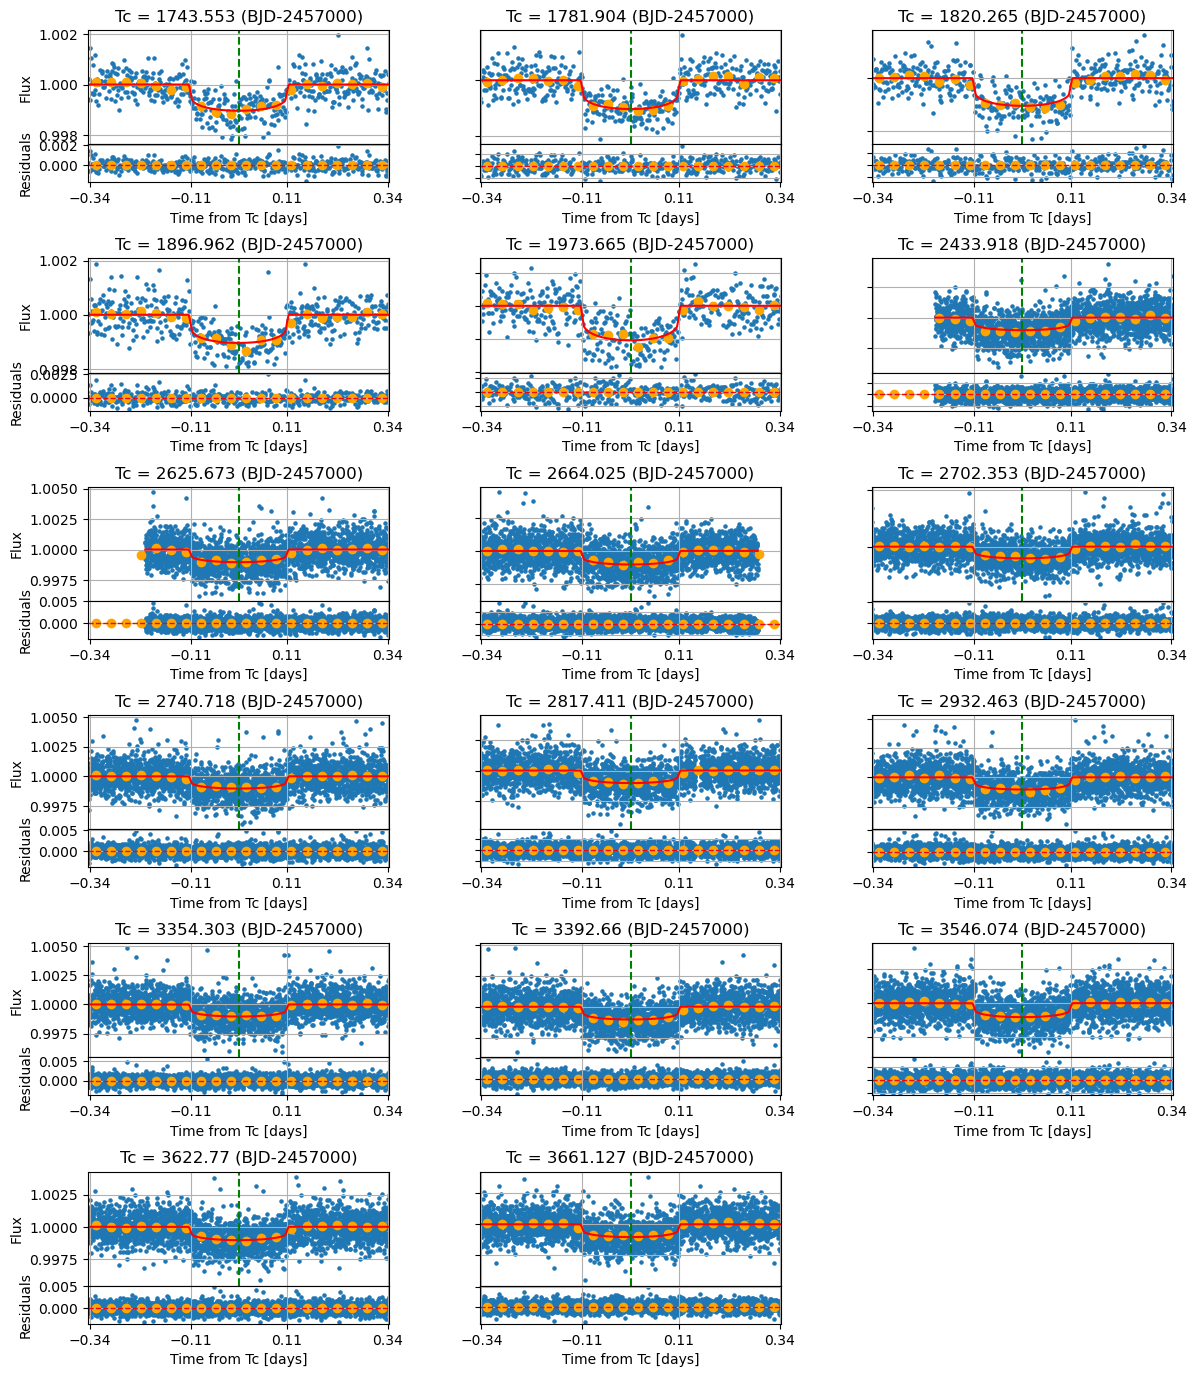

In [289]:
# time= np.array(time)
# tc_chi_d = np.array(tc_chi_d)
# plot_transits(time, flux, flux_err, 
#               tc_chi_d, 
#               per_d, rp_d, b_d, T14_d, u1, u2, 
#               buffer=T14_d*1.5, 
#               offset=tess_offset)

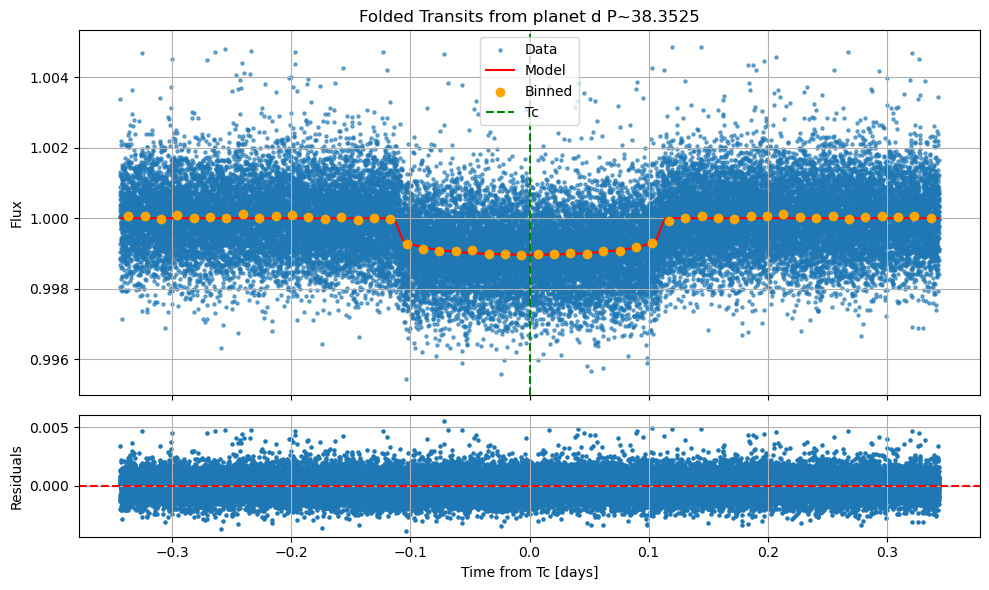

In [306]:
time= np.array(time)
tc_chi_d = np.array(tc_chi_d)
folded_phase_d, folded_flux_d, folded_flux_err_d = plot_folded_from_transits(tc_chi_d, time, flux, 
                                                                             per_d, rp_d, b_d, T14_d, u1, u2, 
                                                                             buffer=T14_d*1.5,
                                                                             title=f'Folded Transits from planet d P~{per_d}')

In [312]:
# Initial guess
theta0 = [rp_d, b_d, T14_d]  # rp, b, T14
res = minimize(transit_chi2, theta0, args=(folded_phase_d, folded_flux_d, folded_flux_err_d))

best_rp_d, best_b_d, best_T14_d = res.x
print("Initial guess:", rp_d, b_d, T14_d, T14_d/0.0416667)
print("Best-fit parameters:", best_rp_d, best_b_d, best_T14_d, best_T14_d/0.0416667)

Initial guess: 0.0302 0.48 0.22916685 5.5
Best-fit parameters: 0.030175049085095433 0.45817497255869966 0.23025113709730888 5.526022869517117


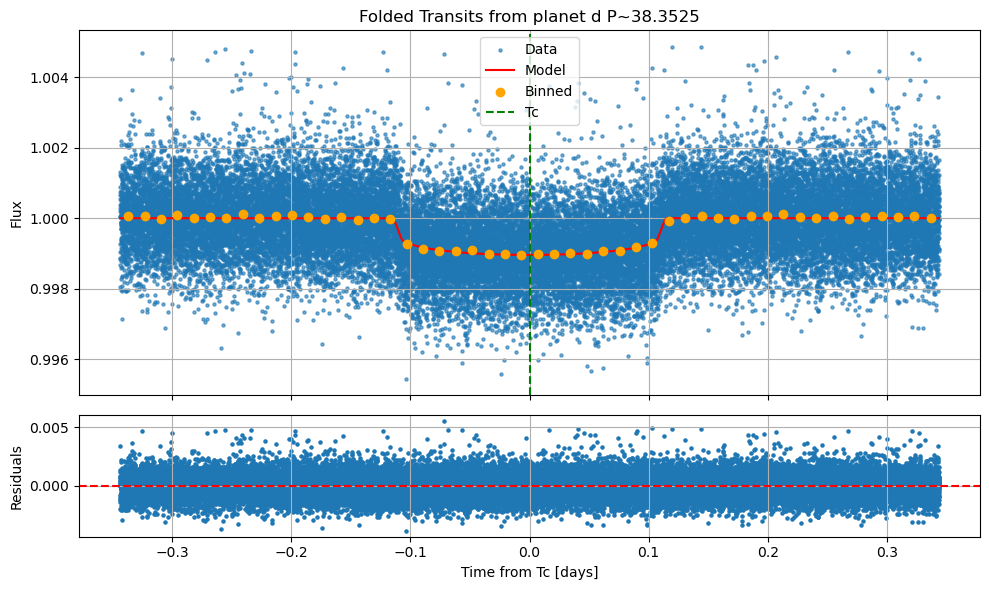

In [308]:
time= np.array(time)
tc_chi_d = np.array(tc_chi_d)
folded_phase_d, folded_flux_d, folded_flux_err_d = plot_folded_from_transits(tc_chi_d, time, flux, 
                                                                             per_d, best_rp_d, best_b_d, best_T14_d, u1, u2, 
                                                                             buffer=T14_d*1.5,
                                                                             title=f'Folded Transits from planet d P~{per_d}')

/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_13686/3964640797.py:40: RuntimeWarning: Mean of empty slice.
  bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]


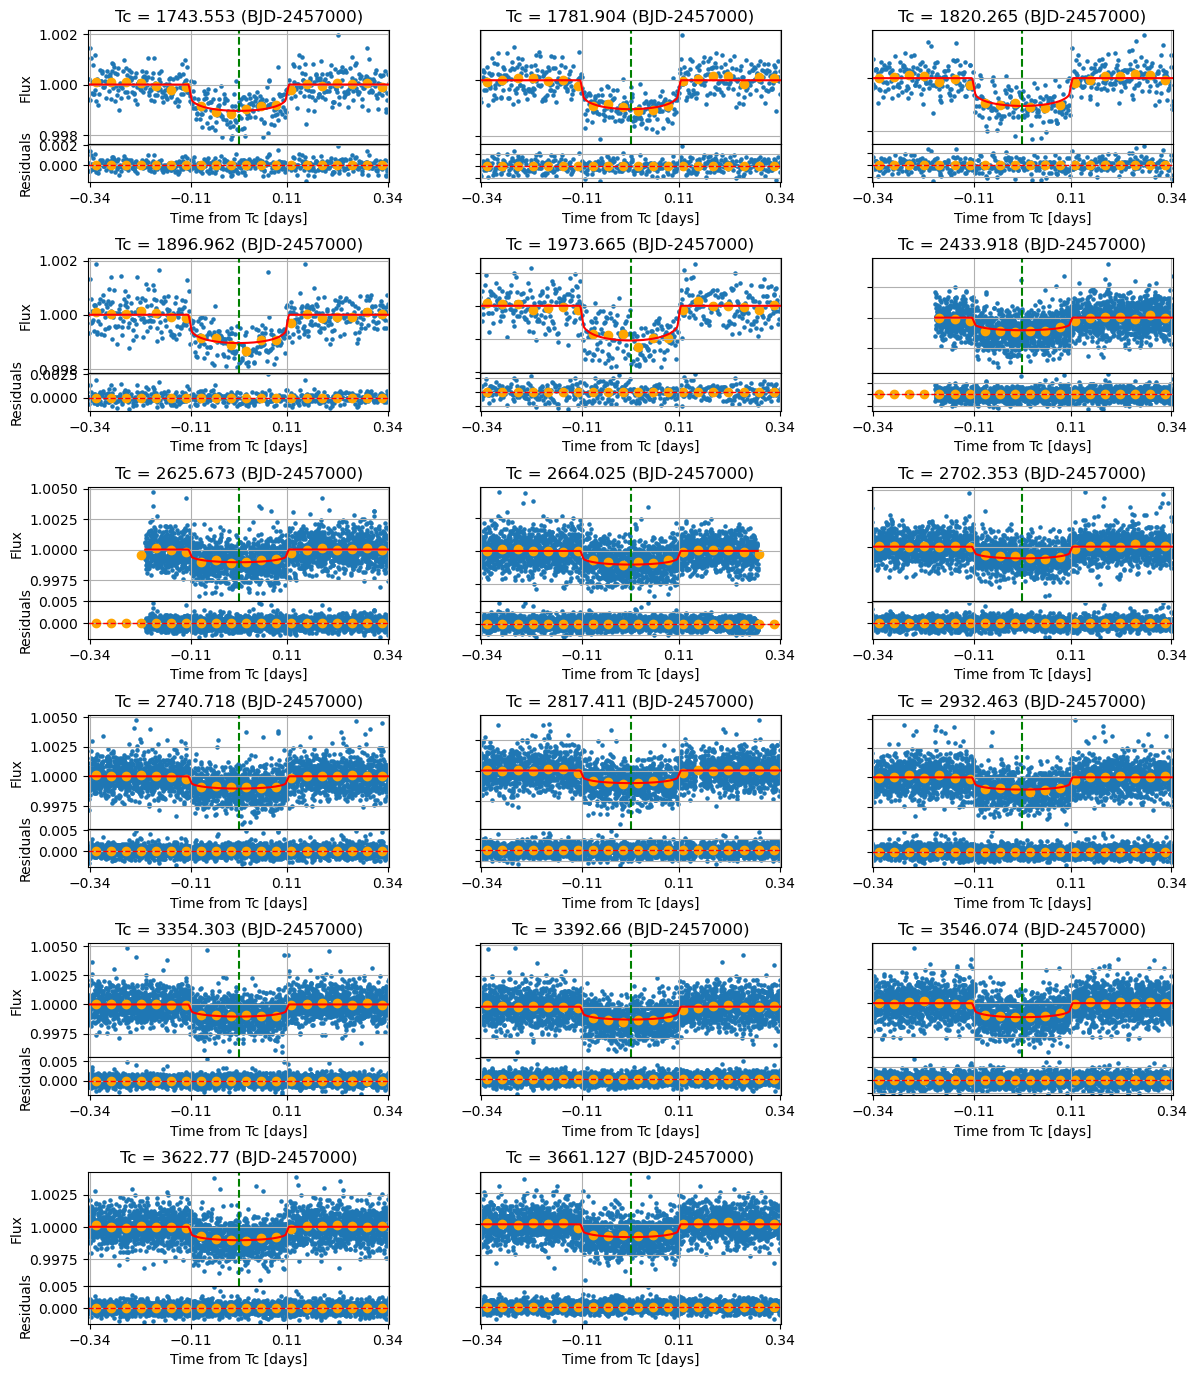

In [317]:
time= np.array(time)
tc_chi_d = np.array(tc_chi_d)
plot_transits(time, flux, flux_err, 
              tc_chi_d, 
              per_d, best_rp_d, best_b_d, best_T14_d, u1, u2, 
              buffer=T14_d*1.5, 
              offset=tess_offset)

In [291]:
print(len(tc_chi_d))

17


# Save Data

In [129]:
# Calculate the indices of transits for each planet
indices_b = np.round((tc_chi_b - Tc_b_guess) / P_b_guess).astype(int)
indices_c = np.round((tc_chi_c - Tc_c_guess) / P_c_guess).astype(int)
indices_d = np.round((tc_chi_d - Tc_d_guess) / P_d_guess).astype(int)

print(indices_b)
print(indices_c)
print(indices_d)


[  0   2   3   5   6   8   9  10  11  12  13  14  18  20  21  22  23  28
  29  30  31  32  33  80  81  82 102 103 105 106 111 113 114 115 122 123
 124 125 126 127 128 135 136 137 138 139 140 178 183 184 185 186 187 188
 189 190 192 194 195 196 197 198 205 206 207 208 209 210 214 216 217 219]
[ 0  1  2  3  4  6  7 25 32 34 35 38 39 42 55 57 58 60 64 65 66 67]
[ 0  1  2  4  6 18 23 24 25 26 28 31 42 43 47 49 50]


In [133]:
print(f'Num transits planet b: {len(tc_chi_b)}')
print(f'Num transits planet c: {len(tc_chi_c)}')
print(f'Num transits planet d: {len(tc_chi_d)}')

tc_chi_b = np.array(tc_chi_b)
tc_chi_c = np.array(tc_chi_c)
tc_chi_d = np.array(tc_chi_d)

Num transits planet b: 72
Num transits planet c: 22
Num transits planet d: 17


In [151]:
save_all = True

In [152]:
### saving data

planet_number = []
if save_all:
    for i in range(len(tc_chi_b)):
        planet_number.append(1)
for i in range(len(tc_chi_c)):
    planet_number.append(2)
for i in range(len(tc_chi_d)):
    planet_number.append(3)

all_transit_num = [] 
if save_all:
    for i in range(len(indices_b)):
        all_transit_num.append(indices_b[i])
for i in range(len(indices_c)):
    all_transit_num.append(indices_c[i])
for i in range(len(indices_d)):
    all_transit_num.append(indices_d[i])

all_obs_tc = []
if save_all:
    for i in range(len(tc_chi_b)):
        all_obs_tc.append(tc_chi_b[i])
for i in range(len(tc_chi_c)):
    all_obs_tc.append(tc_chi_c[i])
for i in range(len(tc_chi_d)):
    all_obs_tc.append(tc_chi_d[i])

all_obs_tc_err = []
if save_all:
    for i in range(len(tc_err_b_comb)):
        all_obs_tc_err.append(tc_err_b_comb[i])
for i in range(len(tc_err_c_comb)):
    all_obs_tc_err.append(tc_err_c_comb[i])
for i in range(len(tc_err_d_comb)):
    all_obs_tc_err.append(tc_err_d_comb[i])

# print(planet_number)
# print(all_transit_num)
# print(all_obs_tc)
# print(all_obs_tc_err)

In [153]:
if save_all:
    output_file = "toi_1339_transit_data_all_planets.txt"
else:
    output_file = "toi_1339_transit_data_all.txt"
### save
data_to_save = np.column_stack((planet_number, all_transit_num, all_obs_tc, all_obs_tc_err))

### Define header
header = "Planet_num Index Tc Tc_err"

### Save to file
np.savetxt(output_file, data_to_save, fmt='%d %d %.8f %.8f', header=header, comments='')

print(f"Results saved to {output_file}")

Results saved to toi_1339_transit_data_all_planets.txt


In [142]:
### create file for table in paper 
# Map planet numbers to labels (e.g., 1 -> b, 2 -> c, 3 -> d)
planet_labels = {1: "b", 2: "c", 3: "d"}  # adjust if your naming differs

# Output file name
output_file = "toi_1339_transit_data_all_planets_formatted.txt"

with open(output_file, "w") as f:
    f.write("% planet, transit index, instrument, time, time_error, notes\n")
    for p, idx, t, terr in zip(planet_number, all_transit_num, all_obs_tc, all_obs_tc_err):
        planet = planet_labels[p]
        instrument = "TESS"
        notes = "A"   # you can change this if needed
        f.write(f"{planet} & {idx} & {instrument} & {t:.4f} & {terr:.4f} & {notes} \\\\\n")

print(f"Formatted results saved to {output_file}")

Formatted results saved to toi_1339_transit_data_all_planets_formatted.txt
